# 3. Modelo base: regresión de la lluvia semanal

**Objetivo:** lluvia acumulada en la semana $h$ posterior a la emisión, $y_h(t)$, en mm ($10\,y_h$ m³/ha). Se emite un pronóstico por semana (los lunes).

**Modelos comparados** para cada horizonte:

- `DummyRegressor` (media de entrenamiento): **línea base trivial** exigida por la guía.
- Climatología: media de entrenamiento para la misma semana del año (referencia exigente).
- Ingenuo estacional: la lluvia de la misma ventana un año antes.
- **SVR lineal** en `Pipeline` (imputación → escalado → `LinearSVR`). Por validación cruzada temporal se eligen $C$, la pérdida (cuadrática o $\varepsilon$-insensible) y si el objetivo se transforma con log1p.

**Predictoras:** solo variables del Excel de NASA POWER (lluvia, temperatura, humedad, viento, radiación, presión y humedad del suelo), resumidas con ventanas del pasado, más armónicos del calendario.

**Partición:** con un solo sitio (plan B), cronológica: entrenamiento 1981–2020 con purga y prueba 2021–2025. Con la grilla regional, entrenamiento en los demás sitios y prueba en la finca (sitio no visto). La validación cruzada es de ventana creciente con `gap` = 7h + latencia días.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
np.random.seed(cfg.SEED)
plt.rcParams["figure.dpi"] = 110
from scipy import stats
from sklearn.metrics import mean_squared_error
from src import modelado as md, espacial as esp

df = pd.read_csv(cfg.DATA_PROCESSED / cfg.ARCHIVO_DATOS, parse_dates=["fecha"])
UN_SITIO = df["punto"].nunique() == 1
particion = md.particion_cronologica if UN_SITIO else md.particion_sitio_futuro
print("Esquema:", "cronológico (un sitio)" if UN_SITIO else "sitio no visto y años futuros")

Esquema: cronológico (un sitio)


## 3.1 Evaluación por horizonte

In [2]:
filas, cvs, periodos, AJ = [], [], [], {}
for h in cfg.HORIZONTES_SEMANAS:
    tabla = md.tabla_modelado(df, h)
    cols = md.columnas_predictoras(tabla)
    tr, te = particion(tabla, h)
    tr = tr.sort_values(["fecha", "punto"]).reset_index(drop=True)
    te = te.sort_values(["fecha", "punto"]).reset_index(drop=True)
    sp = list(md.cv_temporal(tr.fecha, gap_dias=cfg.DIAS_POR_SEMANA * h + cfg.LATENCIA_DIAS))
    modelo, mejor, rmse_cv, grilla = md.ajustar_svr(tr, cols, sp)

    # Habilidad en validación cruzada con la configuración elegida
    es, ec = [], []
    for a, b in sp:
        m = md.pipeline_svr(C=mejor["C"], log_objetivo=bool(mejor["log1p"]), loss=mejor["loss"]).fit(tr.loc[a, cols], tr.loc[a, "y"])
        es.append(np.sqrt(mean_squared_error(tr.loc[b, "y"], m.predict(tr.loc[b, cols]))))
        ec.append(np.sqrt(mean_squared_error(tr.loc[b, "y"], md.climatologia(tr.loc[a], h=h)(tr.loc[b]))))
    ss = 1 - np.array(es) / np.array(ec)

    # Intervalos conformales con los residuos del último fold
    a, b = sp[-1]
    mc = md.pipeline_svr(C=mejor["C"], log_objetivo=bool(mejor["log1p"]), loss=mejor["loss"]).fit(tr.loc[a, cols], tr.loc[a, "y"])
    cal = md.cuantiles_conformales(tr.loc[b, "y"], mc.predict(tr.loc[b, cols]), niveles=(0.025, 0.05, 0.5, 0.95, 0.975))

    preds = {"Dummy (media)": md.pipeline_dummy().fit(tr[cols], tr.y).predict(te[cols]),
             "Climatología": md.climatologia(tr, h=h)(te),
             "Ingenuo estacional": te.base_ingenuo_estacional.values,
             "SVR lineal": modelo.predict(te[cols])}
    ref = preds["Climatología"]
    bloque = max(8, h + 4) * te.punto.nunique()
    for nombre, yhat in preds.items():
        ok = ~np.isnan(yhat)
        m = md.metricas(te.y[ok], yhat[ok])
        ci = md.bootstrap_bloques(te.y.values[ok], yhat[ok], ref[ok], largo_bloque=bloque, n_boot=1000)
        filas.append({"h": h, "modelo": nombre, **m, "RMSE_inf": ci.loc["RMSE", "inf"], "RMSE_sup": ci.loc["RMSE", "sup"],
                      "SS": 1 - m["RMSE"] / md.metricas(te.y[ok], ref[ok])["RMSE"],
                      "SS_inf": ci.loc["SS_clim", "inf"], "SS_sup": ci.loc["SS_clim", "sup"], "n_test": int(ok.sum())})
    q = md.aplicar_intervalo(preds["SVR lineal"], cal)
    cvs.append({"h": h, **mejor, "SS_cv_media": ss.mean(), "SS_cv_min": ss.min(), "SS_cv_max": ss.max(),
                "folds_positivos": int((ss > 0).sum()),
                "cobertura_95": float(np.mean((te.y >= q[0.025]) & (te.y <= q[0.975]))),
                "cobertura_P5": float(np.mean(te.y >= q[0.05]))})
    AJ[h] = dict(modelo=modelo, cols=cols, cal=cal, tr=tr, te=te.assign(yhat=preds["SVR lineal"], clim=ref), mejor=mejor)
    print(f"h = {h:>2}: {mejor}")

res = pd.DataFrame(filas); cv = pd.DataFrame(cvs)
res.to_csv(cfg.DATA_PROCESSED / "resultados_horizontes.csv", index=False)
# MAPE se reporta como fracción (25,77 = 2.577 %): se infla con semanas de lluvia casi nula
res.round(3).rename(columns={"MAPE_y>0": "MAPE (fracción, y>0)"})

h =  1: {'log1p': False, 'loss': 'squared_epsilon_insensitive', 'C': 0.01, 'RMSE_cv': 22.538134948605393}
h =  2: {'log1p': False, 'loss': 'squared_epsilon_insensitive', 'C': 0.01, 'RMSE_cv': 22.697986262322434}
h =  4: {'log1p': False, 'loss': 'squared_epsilon_insensitive', 'C': 0.01, 'RMSE_cv': 22.553492089502072}
h =  8: {'log1p': False, 'loss': 'squared_epsilon_insensitive', 'C': 0.1, 'RMSE_cv': 23.113488997492443}
h = 13: {'log1p': False, 'loss': 'squared_epsilon_insensitive', 'C': 0.1, 'RMSE_cv': 23.269045927923912}
h = 26: {'log1p': False, 'loss': 'squared_epsilon_insensitive', 'C': 0.1, 'RMSE_cv': 23.614633389814877}
h = 52: {'log1p': False, 'loss': 'squared_epsilon_insensitive', 'C': 0.01, 'RMSE_cv': 24.299577796710864}


,h,modelo,RMSE,MAE,WAPE,"MAPE (fracción, y>0)",R2,RMSE_inf,RMSE_sup,SS,SS_inf,SS_sup,n_test
0,1,Dummy (media),46.46,26.3,0.884,43.3,-0.063,31.46,62.3,-0.072,-0.117,-0.039,260
1,1,Climatología,43.35,21.73,0.731,15.94,0.075,28.8,58.07,0,0,0,260
2,1,Ingenuo estacional,55.29,29.53,0.993,13.72,-0.505,39.95,70.7,-0.275,-0.731,-0.059,260
3,1,SVR lineal,40.28,22.86,0.769,25.77,0.201,26.57,54.27,0.071,0.037,0.107,260
4,2,Dummy (media),46.54,26.38,0.885,43.5,-0.063,31.64,61.94,-0.072,-0.121,-0.04,259
5,2,Climatología,43.43,21.77,0.73,16,0.075,28.88,57.83,0,0,0,259
6,2,Ingenuo estacional,55.39,29.59,0.993,13.77,-0.506,39.66,70.91,-0.275,-0.725,-0.058,259
7,2,SVR lineal,40.57,23.21,0.779,28.42,0.192,27.1,54.16,0.066,0.026,0.108,259
8,4,Dummy (media),46.71,26.49,0.883,43.85,-0.065,32.23,62.4,-0.071,-0.119,-0.038,257
9,4,Climatología,43.59,21.89,0.73,16.12,0.073,29.31,58.26,0,0,0,257


In [3]:
cv.round(3)

,h,log1p,loss,C,RMSE_cv,SS_cv_media,SS_cv_min,SS_cv_max,folds_positivos,cobertura_95,cobertura_P5
0,1,False,squared_epsilon_insensitive,0.01,22.54,0.048,-0.009,0.101,4,0.923,0.923
1,2,False,squared_epsilon_insensitive,0.01,22.7,0.042,-0.029,0.083,4,0.9,0.892
2,4,False,squared_epsilon_insensitive,0.01,22.55,0.045,-0.027,0.091,4,0.883,0.887
3,8,False,squared_epsilon_insensitive,0.1,23.11,0.024,-0.027,0.065,4,0.901,0.877
4,13,False,squared_epsilon_insensitive,0.1,23.27,0.018,-0.022,0.053,3,0.903,0.891
5,26,False,squared_epsilon_insensitive,0.1,23.61,0.014,-0.002,0.035,4,0.894,0.894
6,52,False,squared_epsilon_insensitive,0.01,24.3,-0.001,-0.028,0.024,2,0.928,0.957


**Interpretación.** El SVR lineal supera a la línea base trivial (Dummy) en todos los horizontes. Frente a la climatología, que es la referencia exigente, la mejora en prueba es positiva hasta 26 semanas (a 52 semanas el intervalo de confianza incluye el cero) y en validación cruzada es consistente hasta 8 semanas (4 de 5 bloques positivos). La validación eligió la pérdida cuadrática sin transformar el objetivo: la pérdida ε-insensible y la transformación log producen predicciones cercanas a la mediana, que en una variable tan asimétrica subestiman las semanas lluviosas; la pérdida cuadrática estima la media condicional, coherente con el RMSE. El MAE del SVR es levemente mayor que el de la climatología precisamente porque el modelo optimiza el error cuadrático. MAPE, reportado como fracción (25,8 equivale a 2.580 %), se infla con las semanas de lluvia casi nula y no es interpretable; se usa WAPE. **Nota crítica de la guía:** ningún R² se acerca al 80 % y la mejora sobre la climatología es modesta, lo que descarta un desempeño inflado por fuga y es coherente con la baja predictibilidad de la lluvia semanal.

## 3.2 Horizonte confiable *n*

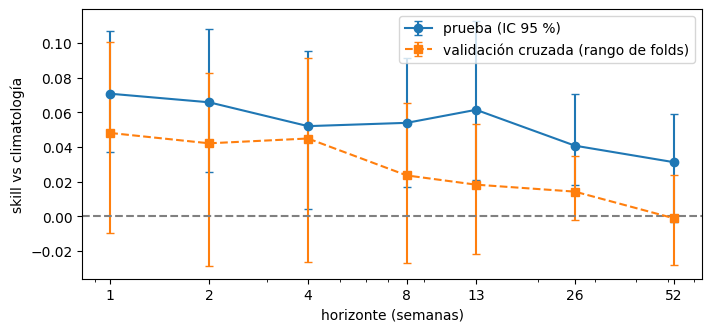

n según prueba: 26 | n según validación (≥ 4 de 5 folds positivos): 8 | n adoptado (conservador): 8


In [4]:
svr = res[res.modelo == "SVR lineal"].reset_index(drop=True)
N_PRUEBA = 0
for _, f in svr.iterrows():
    if f.SS_inf > 0: N_PRUEBA = int(f.h)
    else: break
N_CV = 0
for _, f in cv.iterrows():
    if f.folds_positivos >= 4: N_CV = int(f.h)
    else: break
N_CONFIABLE = min(N_PRUEBA, N_CV)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.errorbar(svr.h, svr.SS, yerr=[svr.SS - svr.SS_inf, svr.SS_sup - svr.SS], fmt="o-", capsize=3, label="prueba (IC 95 %)")
ax.errorbar(cv.h, cv.SS_cv_media, yerr=[cv.SS_cv_media - cv.SS_cv_min, cv.SS_cv_max - cv.SS_cv_media], fmt="s--", capsize=3, label="validación cruzada (rango de folds)")
ax.axhline(0, c="grey", ls="--"); ax.set_xscale("log"); ax.set_xticks(svr.h); ax.set_xticklabels(svr.h)
ax.set_xlabel("horizonte (semanas)"); ax.set_ylabel("skill vs climatología"); ax.legend(); plt.show()
print(f"n según prueba: {N_PRUEBA} | n según validación (≥ 4 de 5 folds positivos): {N_CV} | n adoptado (conservador): {N_CONFIABLE}")

**Interpretación.** La mejora sobre la climatología es de alrededor del 7 % a una semana en prueba y del 5 % en validación cruzada, y decrece con el horizonte. El criterio de prueba sostiene habilidad hasta 26 semanas, y el de validación hasta 8 semanas (a 13 semanas solo 3 de 5 bloques son positivos); se adopta el conservador, **n = 8 semanas**. Más allá, el pronóstico usa los cuantiles climatológicos de la lluvia semanal (sección 3.6).

## 3.3 Cambio de régimen en el periodo de prueba

In [5]:
filas = []
for h, aj in AJ.items():
    te = aj["te"]
    for nombre, g in [("2021", te[te.fecha.dt.year == 2021]), ("2022–2025", te[te.fecha.dt.year >= 2022])]:
        rs, rc = np.sqrt(((g.y - g.yhat) ** 2).mean()), np.sqrt(((g.y - g.clim) ** 2).mean())
        filas.append({"h": h, "periodo": nombre, "RMSE_svr": rs, "RMSE_clim": rc, "SS": 1 - rs / rc, "y_media": g.y.mean()})
print("Lluvia media semanal (objetivo) en entrenamiento y prueba:", round(AJ[1]["tr"].y.mean(), 1), round(AJ[1]["te"].y.mean(), 1))
pd.DataFrame(filas).round(3)

Lluvia media semanal (objetivo) en entrenamiento y prueba: 18.5 29.7


,h,periodo,RMSE_svr,RMSE_clim,SS,y_media
0,1,2021,14.35,19.13,0.25,8.621
1,1,2022–2025,44.46,47.52,0.064,35.02
2,2,2021,14.24,19.06,0.253,8.382
3,2,2022–2025,44.81,47.63,0.059,35.19
4,4,2021,14.53,19.01,0.236,8.174
5,4,2022–2025,45.69,47.86,0.045,35.52
6,8,2021,16.18,17.98,0.1,6.772
7,8,2022–2025,45.8,48.34,0.052,36.23
8,13,2021,20.51,19.2,-0.068,7.621
9,13,2022–2025,45.54,48.82,0.067,36.85


**Interpretación.** El periodo de prueba no es comparable con el entrenamiento: la lluvia semanal media pasa de 18,5 mm a 29,7 mm. Además, sus dos subperiodos son opuestos: 2021 fue mucho más seco que lo habitual (8,6 mm por semana, menos de la mitad de la media de entrenamiento) y ahí el SVR mejora a la climatología en torno al 25 % a una semana; 2022–2025 fue mucho más lluvioso (unos 35 mm por semana, entre 1.700 y 2.000 mm por año) y la mejora baja a cerca del 6 %. Que 2021 sea tan seco pese a ser un año de La Niña, y que 2022–2025 sea tan lluvioso, refuerza la sospecha de un cambio en la fuente de precipitación de POWER en los años recientes; debe verificarse con estaciones del IDEAM. Los errores absolutos de prueba (RMSE cercano a 40 mm) están dominados por ese régimen y no representan el error esperado en años normales (unos 23 mm en validación).

## 3.4 Diagnóstico para h = 1

Breusch-Pagan: LM = 5.57, p = 0.0183
Shapiro-Wilk p = 2.75e-22 | asimetría de residuos = 4.00
Media de los residuos = 1.92 mm (positiva = el modelo subestima)
ACF de residuos: rezago 1 = 0.185 (banda ±0.122); rezagos fuera de la banda: 2 de 26


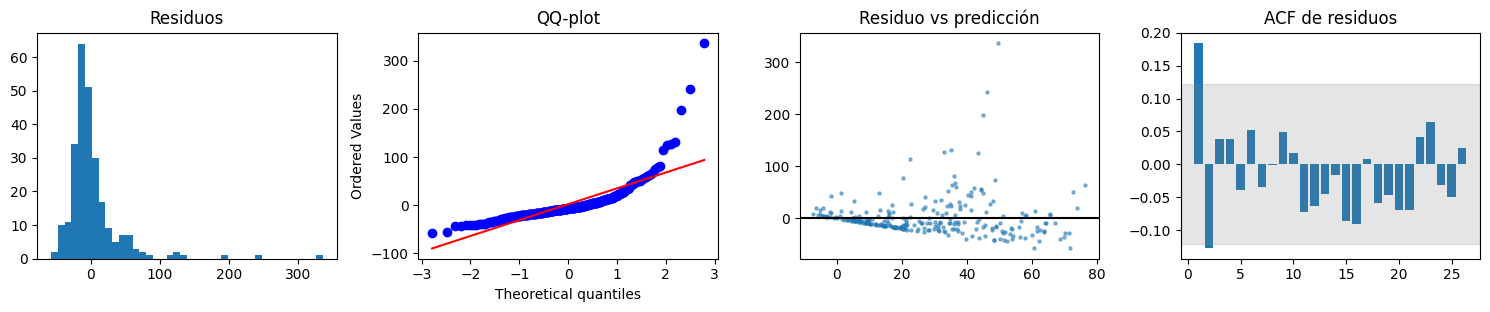

In [6]:
aj = AJ[1]; te = aj["te"].copy(); te["resid"] = te.y - te.yhat
X = np.c_[np.ones(len(te)), te.yhat]; e2 = te.resid ** 2
b_ = np.linalg.lstsq(X, e2, rcond=None)[0]; r2 = 1 - ((e2 - X @ b_) ** 2).sum() / ((e2 - e2.mean()) ** 2).sum()
print(f"Breusch-Pagan: LM = {len(te) * r2:.2f}, p = {stats.chi2.sf(len(te) * r2, 1):.4f}")
print(f"Shapiro-Wilk p = {stats.shapiro(te.resid).pvalue:.2e} | asimetría de residuos = {stats.skew(te.resid):.2f}")
print(f"Media de los residuos = {te.resid.mean():.2f} mm (positiva = el modelo subestima)")
x = te.resid.values - te.resid.mean(); ac = np.array([(x[:-k] @ x[k:]) / (x @ x) for k in range(1, 27)]); b = 1.96 / np.sqrt(len(x))
print(f"ACF de residuos: rezago 1 = {ac[0]:.3f} (banda ±{b:.3f}); rezagos fuera de la banda: {(np.abs(ac) > b).sum()} de 26")
fig, axs = plt.subplots(1, 4, figsize=(15, 3.2))
axs[0].hist(te.resid, bins=40); axs[0].set_title("Residuos")
stats.probplot(te.resid, dist="norm", plot=axs[1]); axs[1].set_title("QQ-plot")
axs[2].scatter(te.yhat, te.resid, s=5, alpha=.5); axs[2].axhline(0, c="k"); axs[2].set_title("Residuo vs predicción")
axs[3].bar(range(1, 27), ac); axs[3].axhspan(-b, b, alpha=.2, color="grey"); axs[3].set_title("ACF de residuos")
plt.tight_layout(); plt.show()

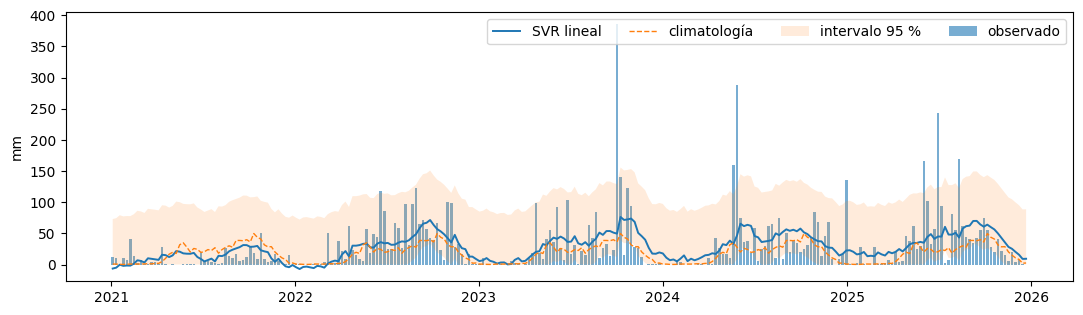

In [7]:
q = md.aplicar_intervalo(te.yhat.values, aj["cal"])
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.bar(te.fecha, te.y, width=5, alpha=.6, label="observado"); ax.plot(te.fecha, te.yhat, lw=1.4, label="SVR lineal")
ax.plot(te.fecha, te.clim, ls="--", lw=1, label="climatología")
ax.fill_between(te.fecha, q[0.025], q[0.975], alpha=.15, label="intervalo 95 %"); ax.legend(ncol=4); ax.set_ylabel("mm"); plt.show()

### Curva de aprendizaje (validación fija 2016–2020)

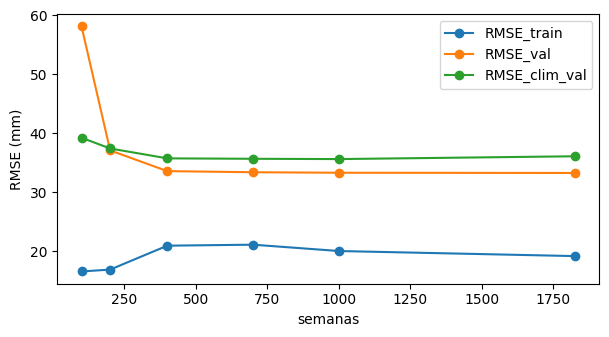

Lluvia semanal media: entrenamiento de la curva 17.4 mm | validación 2016–2020 25.8 mm


,semanas,RMSE_train,RMSE_val,RMSE_clim_val
0,100,16.6,58.13,39.27
1,200,16.92,37.12,37.45
2,400,20.98,33.61,35.78
3,700,21.14,33.42,35.7
4,1000,20.07,33.34,35.66
5,1825,19.21,33.3,36.13


In [8]:
tr = aj["tr"].sort_values("fecha"); cols = aj["cols"]; mj = aj["mejor"]
val = tr[tr.fecha >= "2016-01-01"]; pool = tr[tr.fecha < pd.Timestamp("2016-01-01") - pd.Timedelta(days=10)]
lc = []
for N in [100, 200, 400, 700, 1000, len(pool)]:
    A = pool.tail(N)
    m = md.pipeline_svr(C=mj["C"], log_objetivo=bool(mj["log1p"]), loss=mj["loss"]).fit(A[cols], A.y)
    lc.append([N, np.sqrt(mean_squared_error(A.y, m.predict(A[cols]))), np.sqrt(mean_squared_error(val.y, m.predict(val[cols]))),
               np.sqrt(mean_squared_error(val.y, md.climatologia(A, h=1)(val)))])
lc = pd.DataFrame(lc, columns=["semanas", "RMSE_train", "RMSE_val", "RMSE_clim_val"])
lc.plot(x="semanas", marker="o", figsize=(7, 3.5)); plt.ylabel("RMSE (mm)"); plt.show()
print(f"Lluvia semanal media: entrenamiento de la curva {pool.y.mean():.1f} mm | validación 2016–2020 {val.y.mean():.1f} mm")
lc.round(2)

### Coeficientes (predictoras estandarizadas)

In [9]:
mod = aj["modelo"]; svr_ = mod.named_steps["svr"] if hasattr(mod, "named_steps") else mod.regressor_.named_steps["svr"]
pd.Series(svr_.coef_, index=cols).sort_values(key=np.abs, ascending=False).round(3).head(15)

,0
cos_doy,-5.483
cos2_doy,-5.167
GWETTOP_media_30d,4.357
P_suma_30d,3.667
sin3_doy,3.162
GWETROOT_media_30d,3.066
T2M_media_7d,3.03
ALLSKY_SFC_SW_DWN_media_7d,-2.626
P_suma_90d,2.614
T2M_MAX_media_7d,-2.495


**Interpretación.** Los residuos no son normales (Shapiro-Wilk p < 0,001; asimetría ≈ 4): el modelo no anticipa los aguaceros extremos. Hay heterocedasticidad (Breusch-Pagan p ≈ 0,02): el error crece con la lluvia pronosticada. La media de los residuos es positiva (el modelo subestima en el periodo lluvioso de prueba) y la autocorrelación a un rezago supera la banda de confianza, señal de memoria no capturada. La cobertura del intervalo del 95 % está entre 88 % y 93 %, algo menor que la nominal, coherente con el cambio de régimen. En la curva de aprendizaje el error de validación se estabiliza desde unas 400 semanas y queda por debajo del de la climatología. La brecha entre entrenamiento (unos 19–21 mm) y validación (unos 33 mm) no indica sobreajuste: el periodo de validación 2016–2020 es más lluvioso y variable (25,8 mm por semana de media frente a 17,4 mm) y la climatología también tiene ahí un error alto (unos 36 mm); además, el error de entrenamiento sube con la muestra en lugar de bajar, como ocurre en un modelo muy regularizado. Agregar años del mismo sitio no reduce el error, lo que respalda el diseño regional. Los coeficientes de mayor magnitud son los armónicos del ciclo anual y la humedad del suelo y la lluvia de los últimos 30 días (más agua reciente anticipa más lluvia); más radiación reciente (cielo despejado) reduce la lluvia esperada. Estos hallazgos motivan, para el siguiente entregable, modelos no lineales con pérdida Poisson o Tweedie e intervalos por cuantiles.

## 3.5 Esquema secundario (solo con la grilla regional)

In [10]:
if UN_SITIO:
    print("No aplica con un solo sitio.")
else:
    h = 1; tabla = md.tabla_modelado(df, h); cols = md.columnas_predictoras(tabla)
    tr2, te2 = md.particion_cronologica(tabla, h); mj = AJ[1]["mejor"]
    m2 = md.pipeline_svr(C=mj["C"], log_objetivo=bool(mj["log1p"]), loss=mj["loss"]).fit(tr2[cols], tr2.y)
    te2 = te2.assign(resid=te2.y - m2.predict(te2[cols]))
    coords = df.groupby("punto")[["lat", "lon"]].first()
    W = esp.pesos_inverso_distancia(coords.lat, coords.lon)
    print("I de Moran de los residuos medios por sitio:", esp.moran_i(te2.groupby("punto")["resid"].mean().loc[coords.index].values, W))

No aplica con un solo sitio.


## 3.6 Pronóstico para la planificación

Genera `data/processed/pronostico_lluvia_semanal.csv`, que usa el notebook 04. Para las semanas 1 a *n* (horizonte confiable) se usa el SVR lineal reentrenado con todos los datos y sus intervalos conformales; para las semanas siguientes, cuantiles climatológicos de la lluvia semanal.

In [11]:
g_obj = df[df.punto == cfg.PUNTO_OBJETIVO]
ultima = g_obj.fecha.max()
filas = []
for h in range(1, N_CONFIABLE + 1):
    tabla_h = md.tabla_modelado(df, h)
    cols_h = md.columnas_predictoras(tabla_h)
    tr_h = tabla_h[tabla_h.fecha + pd.Timedelta(days=7 * h) <= ultima]
    h_ref = h if h in AJ else min(AJ, key=lambda k: abs(k - h))
    mj = AJ[h_ref]["mejor"]
    m_h = md.pipeline_svr(C=mj["C"], log_objetivo=bool(mj["log1p"]), loss=mj["loss"]).fit(tr_h[cols_h], tr_h.y)
    X_e = md.construir_predictoras(g_obj.set_index("fecha")).join(md.componentes_ciclicos([ultima], h), how="right")
    for c in ["lat", "lon", "elevacion_m"]:
        X_e[c] = g_obj[c].iloc[0]
    q = md.aplicar_intervalo(m_h.predict(X_e[cols_h]), AJ[h_ref]["cal"])
    filas.append({"semana": h, "fuente": "modelo", **{f"P_q{int(k * 1000):03d}": float(v[0]) for k, v in q.items()}})
sem = g_obj.set_index("fecha")["PRECTOTCORR"].resample("W").sum()
sem_df = pd.DataFrame({"y": sem.values, "woy": sem.index.isocalendar().week.clip(upper=52).values})
for h in range(N_CONFIABLE + 1, 53):
    woy = min(52, int((ultima + pd.Timedelta(days=7 * h - 3)).isocalendar().week))
    v = sem_df[sem_df.woy == woy]["y"]
    filas.append({"semana": h, "fuente": "climatología", **{f"P_q{int(k * 1000):03d}": float(v.quantile(k)) for k in (0.025, 0.05, 0.5, 0.95, 0.975)}})
pronostico = pd.DataFrame(filas)
pronostico.to_csv(cfg.DATA_PROCESSED / "pronostico_lluvia_semanal.csv", index=False)
print(f"Pronóstico desde {ultima.date()}: {N_CONFIABLE} semanas con el modelo y {52 - N_CONFIABLE} con climatología")
pronostico.head(8).round(2)

Pronóstico desde 2025-12-31: 8 semanas con el modelo y 44 con climatología


,semana,fuente,P_q025,P_q050,P_q500,P_q950,P_q975
0,1,modelo,0,0,0.13,56.73,83.21
1,2,modelo,0,0,0.76,57.04,86.31
2,3,modelo,0,0,0.26,56.54,85.8
3,4,modelo,0,0,1.25,57.06,82.53
4,5,modelo,0,0,3.01,58.82,84.29
5,6,modelo,0,0,4.23,60.03,85.5
6,7,modelo,0,0,2.68,64.46,94.34
7,8,modelo,0,0,2.33,64.11,94
